# 03 — Training runner

This notebook runs training from a selected config. The notebook itself
is shared for all experiments; the chosen config string selects the
run.

If you want parallel work, open multiple Colab sessions on the same
notebook and each session picks a different `RUN` value.


## Environment setup

This notebook is not one run per file. Instead:

- one notebook = one runner
- one config = one experiment
- different people can use the same notebook with different config values

In Colab, the notebook runs on a remote VM. If the repo is not already
available there, this notebook will clone it from GitHub. It also stages
data from the shared Drive archive into `/content/data` using the
paths defined in `configs/paths.yaml`.


In [1]:
from pathlib import Path
import subprocess
import sys
import torch
import zipfile

REPO_URL = "https://github.com/FilippoIsoni/sharp-har.git"

# Locate or clone the repository root containing the sharp_har package.
# In Colab, the notebook may run from a temporary working directory.
cwd = Path.cwd().resolve()
if (cwd / "sharp_har").exists():
    REPO_DIR = cwd
elif (cwd.parent / "sharp_har").exists():
    REPO_DIR = cwd.parent
elif (cwd.parent.parent / "sharp_har").exists():
    REPO_DIR = cwd.parent.parent
else:
    REPO_DIR = Path("/content/sharp-har")
    if not REPO_DIR.exists():
        REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

# After the clone, so the file actually exists on a fresh runtime.
!pip install -q -r {REPO_DIR}/requirements.txt

sys.path.insert(0, str(REPO_DIR))

from google.colab import drive
from sharp_har.train import train_run
from sharp_har.utils import read_yaml

paths_cfg = read_yaml(REPO_DIR / "configs" / "paths.yaml")
drive_root = Path(paths_cfg["drive_root"])
stage_dir = Path(paths_cfg["stage_dir"])
CKPT_ROOT = Path(paths_cfg["ckpt_root"])

# Mount Drive unconditionally (idempotent): checkpoints are written to
# CKPT_ROOT on Drive even when the data is already staged on the VM.
drive.mount("/content/drive")

# Stage the zip archives if needed (same convention as 00_setup_smoke).
if not (stage_dir.exists() and any(stage_dir.rglob("*.txt"))):
    stage_dir.mkdir(parents=True, exist_ok=True)
    for zip_name in paths_cfg["zips"]:
        src = drive_root / zip_name
        dst = Path("/content") / zip_name
        print(f"copying {src} -> {dst}")
        subprocess.run(["cp", str(src), str(dst)], check=True)
        with zipfile.ZipFile(dst) as zf:
            zf.extractall(stage_dir)

print("Repo dir:", REPO_DIR)
print("sharp_har exists:", (REPO_DIR / "sharp_har").exists())
print("GPU available:", torch.cuda.is_available())
print("Stage dir:", stage_dir)
print("Checkpoint root:", CKPT_ROOT)


Mounted at /content/drive
copying /content/drive/MyDrive/DATASET_SHARP/doppler_traces.zip -> /content/doppler_traces.zip
copying /content/drive/MyDrive/DATASET_SHARP/doppler_traces_S4_S5.zip -> /content/doppler_traces_S4_S5.zip
Repo dir: /content/sharp-har
sharp_har exists: True
GPU available: True
Stage dir: /content/data
Checkpoint root: /content/drive/MyDrive/sharp_har_runs


## Load config and launch the run

Choose one config stem below and run the cell. The config name
determines which experiment is executed.


In [2]:
RUN = "c2_grl"  # choose one of c0_sharp, c1_ce, c2_grl, c3_supcon, c4_supcon_grl
cfg = read_yaml(REPO_DIR / "configs" / f"{RUN}.yaml")

print("Selected run:", RUN)
print("Config summary:")
print(cfg)

out = train_run(cfg, stage_dir=stage_dir, ckpt_dir=CKPT_ROOT, repo_dir=REPO_DIR)
print("Train run finished:", out)


2026-07-16 15:37:28,009 [INFO] sharp_har.data: train: 81 traces, 53400 (window, antenna) samples (win=340, stride=100)
2026-07-16 15:37:28,019 [INFO] sharp_har.data: val: 9 traces, 1396 (window, antenna) samples (win=340, stride=340)


Selected run: c2_grl
Config summary:
{'name': 'C2', 'protocol': 'P2-lab', 'split_file': 'splits/p2_lab.json', 'backbone': 'resnet_vb', 'd_enc': 256, 'n_att': 8, 'loss': {'type': 'ce', 'label_smoothing': 0.1}, 'adversary': {'type': 'grl', 'target': 'ar_set', 'lambda_max': 1.0, 'beta': None}, 'optim': {'name': 'adamw', 'lr': 0.001, 'wd': 0.0001, 'warmup_epochs': 5, 'scheduler': 'cosine'}, 'train': {'epoch_steps': 400, 'max_epochs': 40, 'batch_size': 256, 'sampler': 'uniform', 'amp': True, 'grad_clip': 1.0}, 'eval': {'select_metric': 'val_macro_f1', 'patience': 10}}


2026-07-16 15:41:26,377 [INFO] sharp_har.train: C2 epoch 1/40: loss 2.0264, val macro-F1 0.1357, arset acc 0.260 (λ=0.245), 0.574 s/step
2026-07-16 15:45:00,419 [INFO] sharp_har.train: C2 epoch 2/40: loss 2.1310, val macro-F1 0.1007, arset acc 0.312 (λ=0.462), 0.527 s/step
2026-07-16 15:48:32,643 [INFO] sharp_har.train: C2 epoch 3/40: loss 2.3213, val macro-F1 0.1808, arset acc 0.309 (λ=0.635), 0.524 s/step
2026-07-16 15:52:03,822 [INFO] sharp_har.train: C2 epoch 4/40: loss 2.4751, val macro-F1 0.4995, arset acc 0.312 (λ=0.762), 0.520 s/step
2026-07-16 15:55:34,490 [INFO] sharp_har.train: C2 epoch 5/40: loss 2.5884, val macro-F1 0.4364, arset acc 0.314 (λ=0.848), 0.520 s/step
2026-07-16 15:59:03,396 [INFO] sharp_har.train: C2 epoch 6/40: loss 2.6467, val macro-F1 0.6177, arset acc 0.315 (λ=0.905), 0.517 s/step
2026-07-16 16:02:31,782 [INFO] sharp_har.train: C2 epoch 7/40: loss 2.6579, val macro-F1 0.3138, arset acc 0.313 (λ=0.941), 0.514 s/step
2026-07-16 16:06:00,475 [INFO] sharp_har.

Train run finished: {'run_dir': PosixPath('/content/drive/MyDrive/sharp_har_runs/C2'), 'best_val_macro_f1': 0.8415456577871268, 'history': [{'epoch': 1, 'train_loss': 2.0263590332865715, 'val_macro_f1': 0.1357162136109505, 'arset_train_acc': 0.260205078125, 'grl_lambda': 0.2449186624037092, 'lr': 0.00020050000000000002, 's_per_step': 0.5741640412807465, 'epoch_seconds': 229.66561651229858}, {'epoch': 2, 'train_loss': 2.1309813904762267, 'val_macro_f1': 0.10069056380900458, 'arset_train_acc': 0.3116796875, 'grl_lambda': 0.4621171572600098, 'lr': 0.00040050000000000003, 's_per_step': 0.5273661255836487, 'epoch_seconds': 210.94645023345947}, {'epoch': 3, 'train_loss': 2.3212700980901717, 'val_macro_f1': 0.18075313807531382, 'arset_train_acc': 0.308994140625, 'grl_lambda': 0.6351489523872873, 'lr': 0.0006005, 's_per_step': 0.5242652583122254, 'epoch_seconds': 209.70610332489014}, {'epoch': 4, 'train_loss': 2.4751430588960646, 'val_macro_f1': 0.49949317738791416, 'arset_train_acc': 0.312294

## Training curves

Per-epoch diagnostics read from the run's `history.csv` (§0.4). The
panels adapt to the run: train loss and throughput always; fused val
macro-F1 with the val-selected best epoch on CE runs (C0/C1/C2); the
mandatory §6-C2 GRL monitoring pair (AR-set train accuracy vs λ ramp)
on C2/C4; learning rate. Re-run this cell any time — it re-reads the
CSV, so it also works on a resumed or still-running run.

Related helpers in `sharp_har.viz`: `plot_confusion(csv)` for the
harness `*_confusion.csv` files, `compare_runs({name: run_dir, ...})`
to overlay a metric across configs (remember §0.5: differences under
~2 points are "comparable", not improvements).


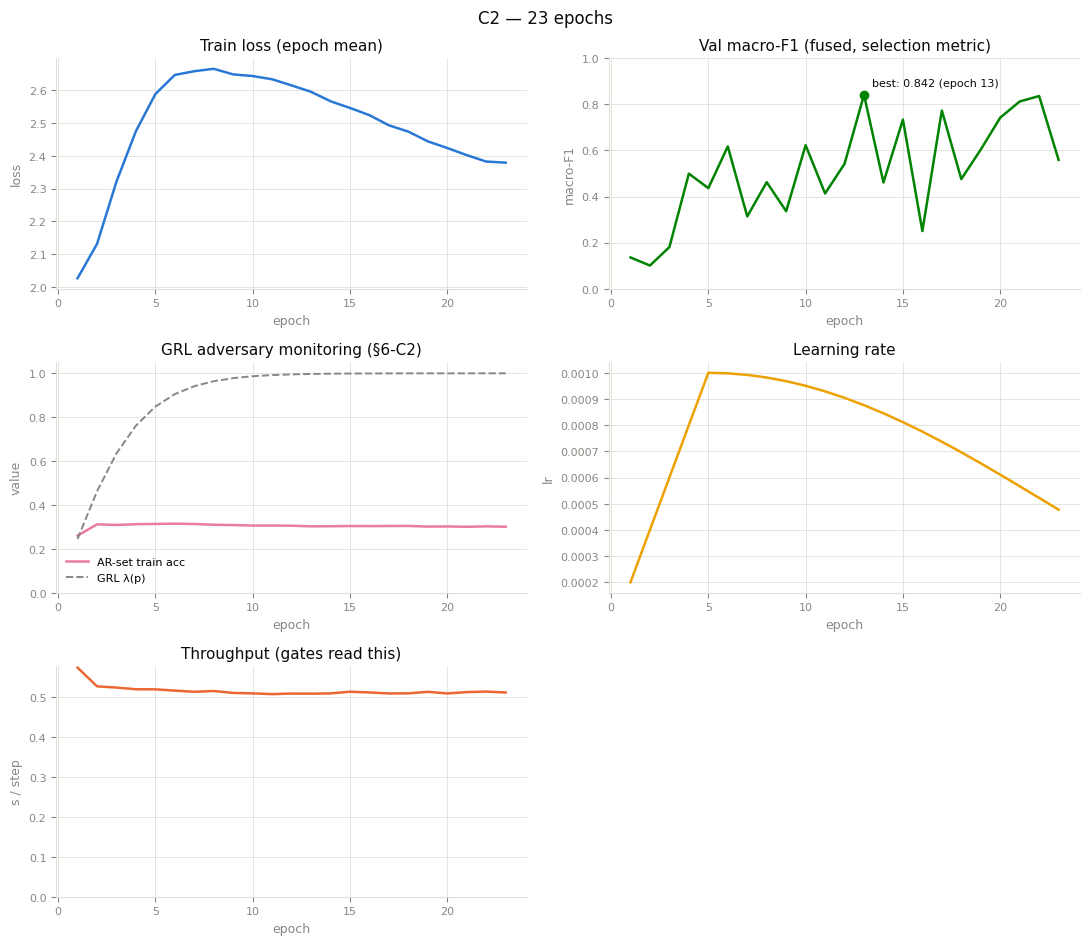

In [3]:
# Thin runner: all plotting logic lives in sharp_har.viz.
from sharp_har.viz import plot_history

run_dir = CKPT_ROOT / cfg["name"]
plot_history(run_dir);


## Archiving the definitive run notebook

This notebook stays a **clean template** (outputs cleared on Git). The
executed copy of a real run is a measured artifact and is committed
verbatim, like the gate reports:

1. When the run (or a resumed segment) ends, download the executed
   notebook (`File → Download → .ipynb`) **with its outputs**.
2. Commit it under `notebooks/runs/` as `YYYY-MM-DD_<config>.ipynb`
   (e.g. `2026-07-16_c0_sharp.ipynb`); add a `_partN` suffix if one run
   spans several resumed sessions. Never edit archived outputs.
3. The run's numeric artifacts still live in `ckpt_root/<name>/`
   (`history.csv`, `run_meta.json`, checkpoints) — the archived
   notebook is the human-readable record, not a data source.

See `notebooks/runs/README.md` for the full convention.
